In [2]:
using CSV, DataFrames, DataFramesMeta, Missings
using StatsBase, Statistics, MatrixLM
using Random, Distributions, StatsModels
using LinearAlgebra, PrettyTables
using FreqTables, Plots, StatsPlots

In [3]:
"""
simulate_bilinear_identity_1level

Simulates X (n×p), true B (p×m) with 1-level subclass hierarchy, and Y (n×m)
under Y = X*B + E (equivalently Z = I).

Arguments:
  n, m, p : dims
  H       : number of subclasses
  prop_sub : length-H vector summing to 1 controlling metabolite proportions per subclass
  theta0_scale : prior SD for theta0[k]
  tau_v   : SD across subclasses (between-subclass variability)
  tau_w   : SD across metabolites within subclass
  sigma_y : residual SD for Y

Returns NamedTuple with X, Y, B_true, theta0, beta, subclass_of_met
"""
function simulate_bilinear_identity_1level(;
    n::Int = 98,
    m::Int = 770,
    p::Int = 10,
    H::Int = 4,
    prop_sub = fill(1/H, H),     # proportions of metabolites per subclass
    theta0_scale::Real = 0.2f0,
    tau_v::Real = 0.15f0,
    tau_w::Real = 0.10f0,
    sigma_y::Real = 1.0f0,
    seed::Int = 123,
    T = Float32
)
    @assert length(prop_sub) == H
    @assert abs(sum(prop_sub) - 1) < 1e-6 "prop_sub must sum to 1"

    Random.seed!(seed)

    # ---- cast scalars to T ---------#
    theta0_scaleT = T(theta0_scale)
    tau_vT        = T(tau_v)
    tau_wT        = T(tau_w)
    sigma_yT      = T(sigma_y)

    # ---- X
    X = randn(T, n, p)

    # ---- build subclass_of_met with controlled proportions
    counts = round.(Int, m .* collect(prop_sub))
    # fix rounding so counts sum to m
    counts[end] += m - sum(counts)

    subclass_of_met = Vector{Int}(undef, m)
    idx = 1
    for h in 1:H
        for _ in 1:counts[h]
            subclass_of_met[idx] = h
            idx += 1
        end
    end
    # shuffle metabolites so subclasses are mixed
    perm = randperm(m)
    subclass_of_met = subclass_of_met[perm]

    # ---- true hierarchical coefficients
    theta0 = rand.(Normal(T(0), theta0_scaleT), p)              # length p

    beta = Matrix{T}(undef, H, p)                               # H × p
    for h in 1:H, k in 1:p
        beta[h, k] = rand(Normal(theta0[k], tau_vT))
    end

    theta = Matrix{T}(undef, m, p)                              # m × p (met × cov)
    for j in 1:m
        h = subclass_of_met[j]
        for k in 1:p
            theta[j, k] = rand(Normal(beta[h, k], tau_wT))
        end
    end

    # B_true is p×m, with B[k,j] = theta[j,k]
    B_true = permutedims(theta)                                 # p × m

    # ---- generate Y = X*B + E
    Y_mean = X * B_true                                         # n × m
    Y = Y_mean .+ randn(T, n, m) .* sigma_yT

    return (X=X, Y=Y, B_true=B_true, theta0=theta0, beta=beta,
            subclass_of_met=subclass_of_met, perm=perm)
end

simulate_bilinear_identity_1level

In [4]:
"""
corrupt_subclass_labels(sub_true, H; rho, seed)

Return a corrupted version of sub_true where approximately rho fraction
of metabolites have their subclass label reassigned uniformly in 1..H.

- rho = 0.0 => identical labels
- rho = 1.0 => fully randomized labels (except chance matches)
"""
function corrupt_subclass_labels(sub_true::Vector{Int}, H::Int; rho::Float64, seed::Int=1)
    @assert 0.0 ≤ rho ≤ 1.0
    m = length(sub_true)
    sub = copy(sub_true)

    if rho == 0.0
        return sub
    end

    Random.seed!(seed)
    nflip = round(Int, rho * m)
    idx = sample(1:m, nflip; replace=false)

    # reassign labels uniformly in 1..H (could reassign to same label by chance)
    @inbounds for j in idx
        sub[j] = rand(1:H)
    end
    return sub
end

corrupt_subclass_labels

In [5]:
sim = simulate_bilinear_identity_1level(n=98, m=770, p=6, H=4,
                                        prop_sub=[0.25, 0.25, 0.25, 0.25], # balanced proportions
                                        theta0_scale=0.2f0,
                                        tau_v=0.12f0, tau_w=0.08f0,
                                        sigma_y=1.0f0, seed=12, T=Float32)

X = sim.X
Y = sim.Y
B_true = sim.B_true
subclass_of_met = sim.subclass_of_met
H = length(unique(subclass_of_met))

4

In [6]:
# center Y matrix
Yc = Y .- mean(Y, dims=1)

98×770 Matrix{Float32}:
  1.97105     0.581971     1.22157    …   1.31865    0.959001    0.0704058
 -0.397028    1.9378       1.27785        0.66921   -2.23077    -0.123867
 -0.695264   -1.43451      0.562154      -0.699391   1.07866    -0.411321
 -0.339796   -1.88825     -1.0929         0.785635  -1.2949      1.30891
  0.48478     0.00929036  -0.915866       0.810651  -0.687755    0.804492
  0.571123   -0.450447    -1.15496    …   0.691421  -0.796221   -0.560865
  1.08879     0.782309     0.908724       0.989689  -2.90473    -0.952254
 -0.662977   -1.82188      0.0953922      0.647613   1.27111     1.33439
 -0.270724    0.68638      1.53218        1.81858    1.44593    -2.21134
  0.0176364  -0.665557     0.879218       1.2925    -0.233305   -1.49674
 -2.22917    -0.0596513    0.639729   …   0.247535  -1.25877    -0.992649
 -0.0548428   1.01829     -0.492791       1.6083     0.727312   -0.140394
  1.40984    -0.214576    -1.0961        -0.195066  -1.75523     0.505993
  ⋮              

In [7]:
"""
Split rows of Y (n×m) and X (n×p) into train/test.

Returns:
  (Y_tr, X_tr, Y_te, X_te, idx_tr, idx_te)
"""
function train_test_split_rows(Y, X; train_frac=0.70, seed=1234, shuffle=true)
    n = size(Y, 1)
    @assert size(X, 1) == n "X and Y must have the same number of rows (individuals)."

    rng = MersenneTwister(seed)
    idx = collect(1:n)
    if shuffle
        Random.shuffle!(rng, idx)
    end

    n_tr = floor(Int, train_frac * n)
    idx_tr = idx[1:n_tr]
    idx_te = idx[n_tr+1:end]

    Y_tr = @view Y[idx_tr, :]
    X_tr = @view X[idx_tr, :]
    Y_te = @view Y[idx_te, :]
    X_te = @view X[idx_te, :]

    return (Y_tr, X_tr, Y_te, X_te, idx_tr, idx_te)
end

# ---- run split COPD Data ----
Y_tr, X_tr, Y_te, X_te, idx_tr, idx_te =
    train_test_split_rows(Yc, X; train_frac=0.70, seed=5)

@show size(Y_tr) size(X_tr) size(Y_te) size(X_te)
@show length(idx_tr) length(idx_te)

size(Y_tr) = (68, 770)
size(X_tr) = (68, 6)
size(Y_te) = (30, 770)
size(X_te) = (30, 6)
length(idx_tr) = 68
length(idx_te) = 30


30

In [8]:
"""
fit_matrixlm_identity(X, Y)

Returns:
B_hat (p×m), SE_hat (p×m), tstat (p×m), fitobj
"""
function fit_matrixlm_identity(X::AbstractMatrix, Y::AbstractMatrix)
    n, p = size(X)
    n2, m = size(Y)
    @assert n == n2

    Z = Diagonal(ones(m))  # identity without forming dense m×m

    fit = mlm(RawData(Response(Y), Predictors(X, Z)), addXIntercept=false, addZIntercept=false)
    B_hat = MatrixLM.coef(fit)
    tstat = MatrixLM.t_stat(fit)

    # SE = |coef|/|t|
    SE_hat = similar(B_hat)
    @inbounds for k in 1:size(B_hat,1), j in 1:size(B_hat,2)
        denom = max(abs(tstat[k,j]), eps(Float64))
        SE_hat[k,j] = abs(B_hat[k,j]) / denom
    end
    return B_hat, SE_hat, tstat, fit
end

fit_matrixlm_identity

In [9]:
# MatrixLM
B_hat, SE_hat, tstat, fit = fit_matrixlm_identity(X_tr, Y_tr)

([0.08477096619157676 -0.17594671631079148 … 0.07822600297850994 0.1054209006299151; 0.429454236098947 0.15655513133216947 … 0.31322891780407286 -0.12606926829675863; … ; 0.08071930026558433 0.015480202738743808 … 0.15981794606999192 0.2675223987505882; 0.0967470278097964 -0.034737271163372774 … 0.22918927557836233 0.07751253849210515], [0.11442562068051199 0.11181458816105178 … 0.11913150441946382 0.10246605888699424; 0.11919120315238922 0.11647142671059556 … 0.1240930768884035 0.10673355117840695; … ; 0.12351776106708402 0.1206992586289146 … 0.12859756941612735 0.1106079049763463; 0.13252536706600276 0.12950132366554024 … 0.1379756234523397 0.11867405206147412], [0.7408390331415894 -1.5735577906647316 … 0.6566357351039152 1.0288372732885105; 3.6030698972799025 1.344150541927958 … 2.5241449858299396 -1.1811587537833506; … ; 0.6535035898338918 0.12825433158903748 … 1.2427757911414246 2.418655328548157; 0.7300264843757243 -0.26823873440157137 … 1.6610852688593223 0.6531548990334722], Ml

In [10]:
# Gibbs Sampler for 1-level hierarchical model

function gibbs_meta_hier_traces_db(
    b_obs::Vector{Float64},           # length m
    se_obs::Vector{Float64},          # length m
    subclass_of_met::Vector{Int},     # length m, values in 1..H (Total subclass)
    H::Int;                           # number of subclasses
    mu0::Float64 = 0.0,
    s0::Float64 = 1.0,
    halfcauchy_scale::Float64 = 1.0,
    n_iter::Int = 2000,
    burnin::Int = 500,
    thin::Int = 1,
    seed::Int = 1234,
)
    @assert length(b_obs) == length(se_obs) "b_obs and se_obs must have same length"
    @assert length(subclass_of_met) == length(b_obs) "subclass_of_met must have length m"
    @assert maximum(subclass_of_met) == H "subclass_of_met must be in 1..H"
    @assert burnin < n_iter "burnin must be < n_iter"
    @assert thin ≥ 1

    Random.seed!(seed)
    m = length(b_obs)
    lam_j = 1.0 ./ (se_obs .^ 2)  # observation precisions

    # --- initialize state ---
    theta = copy(b_obs)                                     # length m (metabolite-level effects)
    beta  = [mean(theta[subclass_of_met .== h]) for h in 1:H]  # class means
    theta0 = mean(beta)                                     # global mean over classes

    tau_w2 = 1.0   # within-class variance for theta_j | beta_h
    tau_v2 = 1.0   # between-class variance for beta_h | theta0

    lambda_w = 1.0    # IG mixture auxiliaries for half-Cauchy
    lambda_v = 1.0

    # --- precompute group indices ---
    idx_by_sub = [findall(==(h), subclass_of_met) for h in 1:H]

    # --- storage sizes ---
    n_keep = floor(Int, (n_iter - burnin) ÷ thin)

    # scalars per draw (for quick monitoring)
    draws_scalar = DataFrame(
        theta0 = Vector{Float64}(undef, n_keep),
        tau_w2 = Vector{Float64}(undef, n_keep),
        tau_v2 = Vector{Float64}(undef, n_keep),
    )

    # vectors per draw
    beta_draws  = Array{Float64}(undef, H, n_keep)   # columns = kept iters
    theta_draws = Array{Float64}(undef, m, n_keep)

    keep_idx = 0

    for it in 1:n_iter
        #######################
        # 1) update theta_j   #
        #######################
        for j in 1:m
            h = subclass_of_met[j]
            lik_prec   = lam_j[j]
            lik_sum    = lam_j[j] * b_obs[j]
            prior_prec = 1.0 / tau_w2
            prior_mean = beta[h]
            mean_th = (lik_sum + prior_prec * prior_mean) / (lik_prec + prior_prec)
            var_th  = 1.0 / (lik_prec + prior_prec)
            theta[j] = rand(Normal(mean_th, sqrt(var_th)))
        end

        #######################
        # 2) update beta_h    #
        #######################
        for h in 1:H
            J = idx_by_sub[h]
            mh = length(J)

            # likelihood: theta_j | beta_h ~ N(beta_h, tau_w2)
            lik_prec   = mh / tau_w2
            lik_sum    = (1.0 / tau_w2) * sum(theta[J])

            # prior: beta_h | theta0 ~ N(theta0, tau_v2)
            prior_prec = 1.0 / tau_v2
            prior_mean = theta0

            mean_b = (lik_sum + prior_prec * prior_mean) / (lik_prec + prior_prec)
            var_b  = 1.0 / (lik_prec + prior_prec)
            beta[h] = rand(Normal(mean_b, sqrt(var_b)))
        end

        #######################
        # 3) update theta0    #
        #######################
        # beta_h | theta0 ~ N(theta0, tau_v2)
        lik_prec   = H / tau_v2
        lik_sum    = (1.0 / tau_v2) * sum(beta)

        # prior: theta0 ~ N(mu0, s0^2)
        prior_prec = 1.0 / (s0^2)
        prior_mean = mu0

        mean_t0 = (lik_sum + prior_prec * prior_mean) / (lik_prec + prior_prec)
        var_t0  = 1.0 / (lik_prec + prior_prec)
        theta0  = rand(Normal(mean_t0, sqrt(var_t0)))

        ############################################
        # 4) update tau_w2 and tau_v2 via IG mix   #
        ############################################

        # tau_w2: within-class spread of theta_j around beta_{class(j)}
        ssw = sum((theta .- beta[subclass_of_met]).^2)
        tau_w2   = rand(InverseGamma((m + 1.0) / 2.0, 0.5 * ssw + 1.0 / lambda_w))
        lambda_w = rand(InverseGamma(1.0, 1.0 / (halfcauchy_scale^2) + 1.0 / tau_w2))

        # tau_v2: between-class spread of beta_h around theta0
        ssv = sum((beta .- theta0).^2)
        tau_v2   = rand(InverseGamma((H + 1.0) / 2.0, 0.5 * ssv + 1.0 / lambda_v))
        lambda_v = rand(InverseGamma(1.0, 1.0 / (halfcauchy_scale^2) + 1.0 / tau_v2))

        ###################################
        # 5) store post-burn (with thin) #
        ###################################
        if it > burnin && ((it - burnin) % thin == 0)
            keep_idx += 1
            draws_scalar.theta0[keep_idx] = theta0
            draws_scalar.tau_w2[keep_idx] = tau_w2
            draws_scalar.tau_v2[keep_idx] = tau_v2

            beta_draws[:, keep_idx]  .= beta
            theta_draws[:, keep_idx] .= theta
        end
    end

    return (; draws_scalar,
            beta_draws,
            theta_draws,
            last_state = (; theta0, tau_w2, tau_v2,
                          beta = copy(beta), theta = copy(theta)))
end

gibbs_meta_hier_traces_db (generic function with 1 method)

In [11]:
"""
Given theta_draws (m × n_keep), return:
  mean_theta :: Vector{Float64} length m
  sd_theta   :: Vector{Float64} length m
"""
function summarize_theta_draws(theta_draws::AbstractMatrix{<:Real})
    m, n_keep = size(theta_draws)
    mean_theta = vec(mean(theta_draws; dims=2))
    sd_theta   = vec(std(theta_draws; dims=2, corrected=true))
    return mean_theta, sd_theta
end

summarize_theta_draws

In [12]:
"""
Run Gibbs meta-hierarchy for each covariate (row of B_obs/SE_obs).

Returns:
  B_bayes  :: Matrix{Float64}  (p×m) posterior means
  SE_bayes :: Matrix{Float64}  (p×m) posterior SDs   (NOT frequentist SEs)
  res_list :: Vector           results per covariate (optional to keep)
"""
function fit_bayes_all_covariates(
    B_obs::AbstractMatrix{<:Real},          # p×m
    SE_obs::AbstractMatrix{<:Real},         # p×m
    subclass_of_met::Vector{Int},
    H::Int;
    mu0::Float64 = 0.0,
    s0::Float64 = 1.0,
    halfcauchy_scale::Float64 = 1.0,
    n_iter::Int = 5000,
    burnin::Int = 1000,
    thin::Int = 1,
    seed0::Int = 42,
    keep_results::Bool = false
)
    p, m = size(B_obs)
    @assert size(SE_obs) == (p, m) "SE_obs must have same shape as B_obs"

    B_bayes  = Array{Float64}(undef, p, m)
    SE_bayes = Array{Float64}(undef, p, m)

    res_list = keep_results ? Vector{Any}(undef, p) : Any[]

    for k in 1:p
        b_vec  = vec(Float64.(B_obs[k, :]))
        se_vec = vec(Float64.(SE_obs[k, :]))

        #mu0 = mu0_mode === :empirical ? mean(b_vec) : 0.0

        res_k = gibbs_meta_hier_traces_db(
            b_vec, se_vec, subclass_of_met, H;
            mu0 = mu0, s0 = s0,
            halfcauchy_scale = halfcauchy_scale,
            n_iter = n_iter, burnin = burnin, thin = thin,
            seed = seed0 + k
        )

        @assert res_k.theta_draws !== nothing "theta_draws missing; ensure save_theta=true"

        mean_theta, sd_theta = summarize_theta_draws(res_k.theta_draws)

        # store into row k
        @inbounds begin
            B_bayes[k, :]  .= mean_theta
            SE_bayes[k, :] .= sd_theta
        end

        if keep_results
            res_list[k] = res_k
        end

        println("Done covariate k=$k / $p")
    end

    return B_bayes, SE_bayes, res_list
end

fit_bayes_all_covariates

In [13]:
B_bayes_tr, SE_bayes_tr, res_by_cov =
    fit_bayes_all_covariates(
        B_hat, SE_hat,
        subclass_of_met, H;
        mu0 = 0.0,      
        s0 = 1.0,
        n_iter = 5000, burnin = 1000, thin = 1,
        seed0 = 1000,
        keep_results = false
    )

@show size(B_bayes_tr) size(SE_bayes_tr)

Done covariate k=1 / 6
Done covariate k=2 / 6
Done covariate k=3 / 6
Done covariate k=4 / 6
Done covariate k=5 / 6
Done covariate k=6 / 6
size(B_bayes_tr) = (6, 770)
size(SE_bayes_tr) = (6, 770)


(6, 770)

In [14]:
mse_coef_mlm  = mean((B_hat .- B_true).^2)
mse_coef_bays = mean((B_bayes_tr .- B_true).^2)

println("Coef MSE (MatrixLM): ", mse_coef_mlm)
println("Coef MSE (Bayes):    ", mse_coef_bays)
println("Ratio of Coef MSE (MatrixLM / Bayes): ",
        (mse_coef_mlm  / mse_coef_bays))

Coef MSE (MatrixLM): 0.015255531612656952
Coef MSE (Bayes):    0.004625125020177808
Ratio of Coef MSE (MatrixLM / Bayes): 3.2984041612069697


In [15]:
"""
Predict Yhat and compute MSE summaries.

Inputs
  Y_te :: (n_te × m) matrix
  X_te :: (n_te × p) matrix
  B    :: (p × m) coefficient matrix

Returns
  mse_all :: Float64
  mse_met :: Vector{Float64} length m   (MSE per metabolite)
  mse_ind :: Vector{Float64} length n_te (MSE per individual)
"""
function test_mse(Y_te::AbstractMatrix{<:Real},
                  X_te::AbstractMatrix{<:Real},
                  B::AbstractMatrix{<:Real})

    n_te, m = size(Y_te)
    @assert size(X_te, 1) == n_te "X_te and Y_te must have same number of rows"
    p = size(X_te, 2)
    @assert size(B) == (p, m) "B must be p×m with p=size(X_te,2), m=size(Y_te,2)"

    # predictions
    Yhat = X_te * B                       # n_te × m
    R = Y_te .- Yhat                      # residuals

    mse_all = mean(abs2, R)               # overall mean squared error
    mse_met = vec(mean(abs2, R; dims=1))  # average over individuals -> per metabolite
    mse_ind = vec(mean(abs2, R; dims=2))  # average over metabolites -> per individual

    return mse_all, mse_met, mse_ind
end

test_mse

In [17]:
# Ensure Float64 (optional but avoids mixed types)
Y_te_f = Float64.(Y_te)
X_te_f = Float64.(X_te)

B_mlm  = Float64.(B_hat)
B_bys  = Float64.(B_bayes_tr)

mse_mlm, mse_mlm_met, mse_mlm_ind = test_mse(Y_te_f, X_te_f, B_mlm)
mse_bys, mse_bys_met, mse_bys_ind = test_mse(Y_te_f, X_te_f, B_bys)

println("Test MSE (MatrixLM): ", mse_mlm)
println("Test MSE (Bayes):    ", mse_bys)
println("Ratio of Test MSE (MatrixLM / Bayes): ",
        (mse_mlm / mse_bys))

Test MSE (MatrixLM): 1.0755549234189303
Test MSE (Bayes):    1.0049701891294378
Ratio of Test MSE (MatrixLM / Bayes): 1.070235649826227


In [18]:
# Coef MSE vs truth (both p x m)
coef_mse(B_est::AbstractMatrix, B_true::AbstractMatrix) = mean((B_est .- B_true) .^ 2)

# Test MSE on Yhat = X * B (Y is n x m, X is n x p, B is p x m)
test_mse(Y::AbstractMatrix, X::AbstractMatrix, B::AbstractMatrix) = mean((Y .- (X * B)) .^ 2)

test_mse (generic function with 2 methods)

In [38]:
"""
run_wrong_hierarchy_study

Compare:
  - MatrixLM (train) vs truth
  - Bayes with true subclass labels (oracle)
  - Bayes with corrupted subclass labels at multiple rho values

Returns:
  (per_run = DataFrame, summary = DataFrame)
"""
function run_wrong_hierarchy_study(;
    # grid
    rhos::Vector{Float64} = [0.0, 0.1, 0.25, 0.4, 0.6, 0.8, 1.0],
    regimes = [
        (name="strong_hetero", tau_v=0.25f0, tau_w=0.01f0),
        (name="weak_hetero",   tau_v=0.01f0, tau_w=0.08f0),
    ],
    nrep::Int = 10,

    # simulation base kwargs
    sim_base = (; n=98, m=770, p=10, H=4,
                prop_sub=[0.25,0.25, 0.25, 0.25],
                theta0_scale=0.2f0,
                sigma_y=0.1f0,
                T=Float32),

    split_frac::Float64 = 0.70,
    seed_base::Int = 1,

    # Bayes settings
    bayes_mu0::Float64 = 0.0,
    bayes_s0::Float64 = 1.0,
    bayes_halfcauchy_scale::Float64 = 1.0,
    bayes_n_iter::Int = 2000,
    bayes_burnin::Int = 500,
    bayes_thin::Int = 1,
)
    rows = Vector{NamedTuple}()

    for reg in regimes
        reg_name = reg.name
        tau_v = reg.tau_v
        tau_w = reg.tau_w

        for r in 1:nrep
            sim_seed = Int(seed_base + 100_000 * (hash(reg_name) % 10_000) + 10_000 * r)

            # --- (1) simulate one dataset ---
            sim = simulate_bilinear_identity_1level(; sim_base..., tau_v=tau_v, tau_w=tau_w, seed=sim_seed)
            X = sim.X
            Y = sim.Y
            B_true = sim.B_true
            sub_true = sim.subclass_of_met
            H = sim_base.H

            # --- (2) split train/test ---
            (Y_tr, X_tr, Y_te, X_te, _, _) = train_test_split_rows(Y, X; train_frac=split_frac, seed=sim_seed + 777)

            # --- (3) fit MatrixLM on train ---
            (B_hat, SE_hat, tstat, fitobj) = fit_matrixlm_identity(X_tr, Y_tr)

            # --- (4) Bayes with true hierarchy (oracle) ---
            (B_bayes_true, SE_bayes_true, res_true) = fit_bayes_all_covariates(
                B_hat, SE_hat, sub_true, H;
                mu0 = bayes_mu0,
                s0 = bayes_s0,
                halfcauchy_scale = bayes_halfcauchy_scale,
                n_iter = bayes_n_iter,
                burnin = bayes_burnin,
                thin = bayes_thin,
                seed0 = sim_seed + 2000,
                keep_results = false
            )

            # metrics that do NOT depend on rho
            cmse_mlm = coef_mse(Float64.(B_hat), Float64.(B_true))
            cmse_bys_true = coef_mse(Float64.(B_bayes_true), Float64.(B_true))

            tmse_mlm = test_mse(Float64.(Y_te), Float64.(X_te), Float64.(B_hat))[1]
            tmse_bys_true = test_mse(Float64.(Y_te), Float64.(X_te), Float64.(B_bayes_true))[1]

            # --- (5) Bayes with wrong hierarchy for each rho ---
            for rho in rhos
                sub_wrong = corrupt_subclass_labels(sub_true, H; rho=rho, seed=sim_seed + round(Int, 1e6*rho) + 999)

                (B_bayes_wrong, SE_bayes_wrong, res_wrong) = fit_bayes_all_covariates(
                    B_hat, SE_hat, sub_wrong, H;
                    mu0 = bayes_mu0,
                    s0 = bayes_s0,
                    halfcauchy_scale = bayes_halfcauchy_scale,
                    n_iter = bayes_n_iter,
                    burnin = bayes_burnin,
                    thin = bayes_thin,
                    seed0 = sim_seed + 3000 + round(Int, 1e6*rho),
                    keep_results = false
                )

                cmse_bys_wrong = coef_mse(Float64.(B_bayes_wrong), Float64.(B_true))
                tmse_bys_wrong = test_mse(Float64.(Y_te), Float64.(X_te), Float64.(B_bayes_wrong))[1]

                push!(rows, (
                    regime = reg_name,
                    rep = r,
                    rho = rho,

                    coef_mse_mlm = cmse_mlm,
                    coef_mse_bayes_true = cmse_bys_true,
                    coef_mse_bayes_wrong = cmse_bys_wrong,

                    test_mse_mlm = tmse_mlm,
                    test_mse_bayes_true = tmse_bys_true,
                    test_mse_bayes_wrong = tmse_bys_wrong,

                    ratio_mlm_coef_wrong = cmse_mlm / cmse_bys_wrong,
                    ratio_mlm_test_wrong = tmse_mlm / tmse_bys_wrong
                ))
                println("regime=$(reg_name) rep=$r rho=$rho  coef_ratio_wrong/mlm=$(cmse_bys_wrong/cmse_mlm)  test_ratio_wrong/mlm=$(tmse_bys_wrong/tmse_mlm)")
            end
        end
    end

    per_run = DataFrame(rows)

    summary = combine(groupby(per_run, [:regime, :rho]),
        :ratio_mlm_coef_wrong => mean => :ratio_coef_mean,
        :ratio_mlm_test_wrong => mean => :ratio_test_mean,
        :coef_mse_mlm => mean => :coef_mse_mlm_mean,
        :coef_mse_bayes_wrong => mean => :coef_mse_bayes_wrong_mean,
        :test_mse_mlm => mean => :test_mse_mlm_mean,
        :test_mse_bayes_wrong => mean => :test_mse_bayes_wrong_mean,
        nrow => :n_runs
    )

    return (per_run=per_run, summary=summary)
end

run_wrong_hierarchy_study

In [39]:
# Run the run_wrong_hierarchy_study simulation

res = run_wrong_hierarchy_study(nrep = 10)

Done covariate k=1 / 10
Done covariate k=2 / 10
Done covariate k=3 / 10
Done covariate k=4 / 10
Done covariate k=5 / 10
Done covariate k=6 / 10
Done covariate k=7 / 10
Done covariate k=8 / 10
Done covariate k=9 / 10
Done covariate k=10 / 10
Done covariate k=1 / 10
Done covariate k=2 / 10
Done covariate k=3 / 10
Done covariate k=4 / 10
Done covariate k=5 / 10
Done covariate k=6 / 10
Done covariate k=7 / 10
Done covariate k=8 / 10
Done covariate k=9 / 10
Done covariate k=10 / 10
regime=strong_hetero rep=1 rho=0.0  coef_ratio_wrong/mlm=0.37626590906181795  test_ratio_wrong/mlm=0.906387514869735
Done covariate k=1 / 10
Done covariate k=2 / 10
Done covariate k=3 / 10
Done covariate k=4 / 10
Done covariate k=5 / 10
Done covariate k=6 / 10
Done covariate k=7 / 10
Done covariate k=8 / 10
Done covariate k=9 / 10
Done covariate k=10 / 10
regime=strong_hetero rep=1 rho=0.1  coef_ratio_wrong/mlm=0.9461738150417038  test_ratio_wrong/mlm=0.9927246103408917
Done covariate k=1 / 10
Done covariate k=2 

(per_run = 140×11 DataFrame
 Row │ regime         rep    rho      coef_mse_mlm  coef_mse_bayes_true  coef_ ⋯
     │ String         Int64  Float64  Float64       Float64              Float ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ strong_hetero      1     0.0    0.000186144          7.01907e-5         ⋯
   2 │ strong_hetero      1     0.1    0.000186144          7.01907e-5
   3 │ strong_hetero      1     0.25   0.000186144          7.01907e-5
   4 │ strong_hetero      1     0.4    0.000186144          7.01907e-5
   5 │ strong_hetero      1     0.6    0.000186144          7.01907e-5         ⋯
   6 │ strong_hetero      1     0.8    0.000186144          7.01907e-5
   7 │ strong_hetero      1     1.0    0.000186144          7.01907e-5
   8 │ strong_hetero      2     0.0    0.000161785          6.52432e-5
   9 │ strong_hetero      2     0.1    0.000161785          6.52432e-5         ⋯
  10 │ strong_hetero      2     0.25   0.000161785          

In [40]:
res.summary

Row,regime,rho,ratio_coef_mean,ratio_test_mean,coef_mse_mlm_mean,coef_mse_bayes_wrong_mean,test_mse_mlm_mean,test_mse_bayes_wrong_mean,n_runs
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64
1,strong_hetero,0.0,2.57123,1.09818,0.000173074,6.72676e-5,0.011787,0.010733,10
2,strong_hetero,0.1,1.03309,1.00468,0.000173074,0.000167551,0.011787,0.0117322,10
3,strong_hetero,0.25,1.01687,1.00244,0.000173074,0.000170209,0.011787,0.0117584,10
4,strong_hetero,0.4,1.01012,1.00139,0.000173074,0.000171353,0.011787,0.0117706,10
5,strong_hetero,0.6,1.00822,1.00112,0.000173074,0.000171669,0.011787,0.0117738,10
6,strong_hetero,0.8,1.00686,1.00101,0.000173074,0.000171899,0.011787,0.0117752,10
7,strong_hetero,1.0,1.00677,1.001,0.000173074,0.000171912,0.011787,0.0117752,10
8,weak_hetero,0.0,1.02831,1.00438,0.000178193,0.000173255,0.0117191,0.0116679,10
9,weak_hetero,0.1,1.02822,1.00432,0.000178193,0.000173272,0.0117191,0.0116687,10


In [84]:
# Plotting function

"""plot_wrong_hierarchy_curve(summary; which)
Plot degradation ratio vs rho from summary DataFrame.
"""

function plot_wrong_hierarchy_curve(summary::DataFrame; which=:ratio_coef_mean)
    @assert which in (:ratio_test_mean, :ratio_coef_mean)
    plt = plot(title="Wrong hierarchy: degradation vs rho",
               xlabel="rho (fraction of labels corrupted)",
               ylabel=string(which),
               legend=:bottomleft)

    for reg in unique(summary.regime)
        df = summary[summary.regime .== reg, :]
        sort!(df, :rho)
        plot!(plt, df.rho, df[!, which], marker=:circle, label=string(reg))
    end

    hline!(plt, [1.0], l=:dash, label="MatrixLM baseline (=1)")
    return plt
end

plot_wrong_hierarchy_curve (generic function with 1 method)

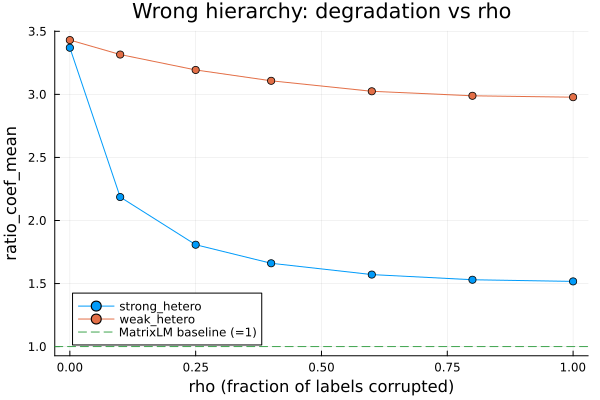

In [85]:
plot_wrong_hierarchy_curve(res.summary; which=:ratio_coef_mean)

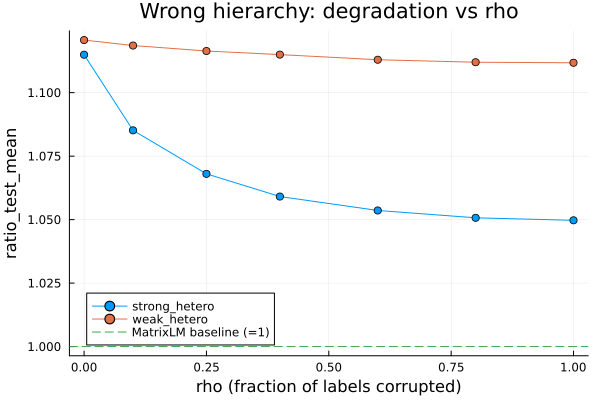

In [87]:
plot_wrong_hierarchy_curve(res.summary; which=:ratio_test_mean)